# Interpretability Visualization

This notebook generates interpretability visualizations for AST (self-attention) model.
Generates 3 individual figures: original spectrogram, attention heatmap and attention overlay.

In [ ]:
import cv2
import librosa  # ty: ignore
import matplotlib.pyplot as plt
import numpy as np
import torch
from transformers import ASTForAudioClassification

%matplotlib inline
%config InlineBackend.figure_format = 'svg'
plt.rcdefaults()  # ty: ignore

In [ ]:
AST_MODEL_PATH = "../models/ast_asthma/final_model"
SAMPLE_AUDIO_PATH = "../data/sample_audio/sample_011_figure_source.wav"
FIGURE_SIZE = (4 * 1.2, 3 * 1.2)

In [ ]:
class ASTWithAttention(torch.nn.Module):
    def __init__(self, model_path: str):
        super().__init__()
        self.ast_model = ASTForAudioClassification.from_pretrained(
            model_path, attn_implementation="eager"
        )
        self.attention_weights = []

    def forward(self, input_values, output_attentions=True):
        self.attention_weights = []
        outputs = self.ast_model(
            input_values, output_attentions=output_attentions, return_dict=True
        )
        if output_attentions:
            self.attention_weights = outputs.attentions
        return outputs

    def get_attention_maps(self, layer_indices: list = [-1]):
        attention_maps = {}
        for layer_idx in layer_indices:
            if self.attention_weights and len(self.attention_weights) > abs(layer_idx):
                attn = self.attention_weights[layer_idx]
                cls_attention = attn[:, :, 0, 1:]
                avg_attention = cls_attention.mean(dim=1)
                attention_maps[layer_idx] = avg_attention
        return attention_maps

In [ ]:
def load_sample_audio(file_path: str):
    sample_waveform, sample_rate = librosa.load(file_path, sr=None, dtype=np.float32)
    return sample_waveform, sample_rate


def create_spectrogram_for_ast(audio_clip, sample_rate):
    if sample_rate != 16000:
        signal = librosa.resample(audio_clip, orig_sr=sample_rate, target_sr=16000)
    else:
        signal = audio_clip

    mel_spec = librosa.feature.melspectrogram(
        y=signal, sr=16000, n_mels=128, n_fft=1024, hop_length=160, fmin=0, fmax=8000
    )
    log_mel_spec = librosa.power_to_db(mel_spec, ref=np.max)
    log_mel_spec = (log_mel_spec - log_mel_spec.mean()) / (log_mel_spec.std() + 1e-8)

    input_tensor = torch.from_numpy(log_mel_spec).float()
    target_time_frames = 1024
    if input_tensor.shape[1] != target_time_frames:
        if input_tensor.shape[1] < target_time_frames:
            pad_size = target_time_frames - input_tensor.shape[1]
            input_tensor = torch.nn.functional.pad(input_tensor, (0, pad_size))
        else:
            input_tensor = input_tensor[:, :target_time_frames]

    input_tensor = input_tensor.unsqueeze(0).transpose(1, 2)
    return log_mel_spec, input_tensor

In [5]:
def reshape_attention_to_2d(attention_vector, patch_size=16, target_shape=(1024, 128)):
    height_patches = target_shape[0] // patch_size
    width_patches = target_shape[1] // patch_size
    expected_patches = height_patches * width_patches

    if len(attention_vector) < expected_patches:
        padded_attention = np.zeros(expected_patches)
        padded_attention[: len(attention_vector)] = attention_vector
        attention_vector = padded_attention
    elif len(attention_vector) > expected_patches:
        attention_vector = attention_vector[:expected_patches]

    attention_2d = attention_vector.reshape(height_patches, width_patches)
    return attention_2d


def upscale_attention_map(attention_2d, target_shape=(1024, 128)):
    upscaled = cv2.resize(
        attention_2d.astype(np.float32),
        (target_shape[1], target_shape[0]),
        interpolation=cv2.INTER_LINEAR,
    )
    return upscaled


def setup_frequency_axis(ax, n_mels=128, fmin=0, fmax=8000, label_lang="ru"):
    """Set up y-axis with frequency labels instead of mel bin indices."""
    # Create mel frequency points
    mel_points = np.linspace(librosa.hz_to_mel(fmin), librosa.hz_to_mel(fmax), n_mels)
    hz_points = librosa.mel_to_hz(mel_points)

    # Select tick positions at regular intervals
    tick_indices = np.arange(0, n_mels, 16)  # Every 16 bins
    tick_frequencies = hz_points[tick_indices]

    # Set ticks and labels
    ax.set_yticks(tick_indices)
    ax.set_yticklabels([f"{int(freq)}" for freq in tick_frequencies])
    ax.set_ylabel("Частота (Hz)" if label_lang == "ru" else "Frequency (Hz)")


def setup_time_axis(ax, total_frames, duration_seconds=5.0, label_lang="ru"):
    """Set up x-axis with time labels in seconds instead of frame indices."""
    # Calculate time points
    tick_positions = np.linspace(
        0, total_frames - 1, 6
    )  # 6 ticks: 0, 1, 2, 3, 4, 5 sec
    tick_labels = np.linspace(0, duration_seconds, 6)

    ax.set_xticks(tick_positions)
    ax.set_xticklabels([f"{t:.1f}" for t in tick_labels])
    ax.set_xlabel("Время (с)" if label_lang == "ru" else "Time (sec)")

In [6]:
ast_model = ASTWithAttention(AST_MODEL_PATH)
ast_model.eval()

# Load audio
audio_clip, sample_rate = load_sample_audio(SAMPLE_AUDIO_PATH)

# Create spectrogram
original_spectrogram, ast_input_tensor = create_spectrogram_for_ast(
    audio_clip, sample_rate
)

In [7]:
# Generate AST attention
with torch.no_grad():
    ast_outputs = ast_model(ast_input_tensor, output_attentions=True)
    attention_maps = ast_model.get_attention_maps([-1])
    attention = attention_maps[-1][0].cpu().numpy()
    attention_2d = reshape_attention_to_2d(
        attention, target_shape=original_spectrogram.shape
    )
    attention_upscaled = upscale_attention_map(
        attention_2d, target_shape=original_spectrogram.shape
    )
    attention_norm = (attention_upscaled - attention_upscaled.min()) / (
        attention_upscaled.max() - attention_upscaled.min()
    )

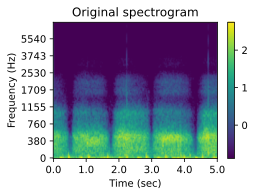

In [ ]:
# Figure A: Original spectrogram
PAPER_FIG_SIZE = (4 * 0.95, 3 * 0.95)
fig, ax = plt.subplots(figsize=PAPER_FIG_SIZE)
im = ax.imshow(original_spectrogram, cmap="viridis", aspect="auto", origin="lower")  # ty: ignore
ax.set_title("Original spectrogram")
setup_time_axis(ax, original_spectrogram.shape[1], label_lang="en")
setup_frequency_axis(ax, label_lang="en")
plt.colorbar(im, ax=ax)  # ty: ignore
plt.tight_layout()  # ty: ignore
plt.show()

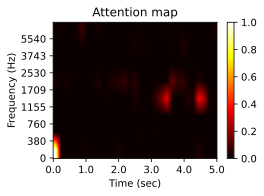

In [ ]:
# Figure D: Attention layer -1 heatmap
fig, ax = plt.subplots(figsize=PAPER_FIG_SIZE)
im = ax.imshow(attention_norm, cmap="hot", aspect="auto", origin="lower")  # ty: ignore
ax.set_title("Attention map")
setup_time_axis(ax, attention_norm.shape[1], label_lang="en")
setup_frequency_axis(ax, label_lang="en")
plt.colorbar(im, ax=ax)  # ty: ignore
plt.tight_layout()  # ty: ignore
plt.show()

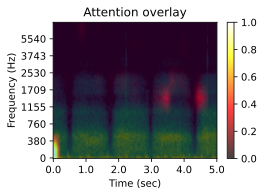

In [ ]:
# Figure E: Attention + original overlay
fig, ax = plt.subplots(figsize=PAPER_FIG_SIZE)
ax.imshow(original_spectrogram, cmap="viridis", aspect="auto", origin="lower")  # ty: ignore
im = ax.imshow(attention_norm, cmap="hot", aspect="auto", alpha=0.75, origin="lower")  # ty: ignore
ax.set_title("Attention overlay")
setup_time_axis(ax, attention_norm.shape[1], label_lang="en")
setup_frequency_axis(ax, label_lang="en")
plt.colorbar(im, ax=ax)  # ty: ignore
plt.tight_layout()  # ty: ignore
plt.show()